# Eksperimen Machine Learning – Plants Type Classification

**Dataset:** [Plants Type Datasets – Kaggle](https://www.kaggle.com/datasets/yudhaislamisulistya/plants-type-datasets)  
**Path:** `/kaggle/input/datasets/yudhaislamisulistya/plants-type-datasets/split_ttv_dataset_type_of_plants`

Notebook ini melakukan eksperimen **manual** meliputi:
1. Import Library
2. Memuat Dataset
3. Exploratory Data Analysis (EDA)
4. Preprocessing

# **1. Perkenalan Dataset**


Dataset **Plants Type** berisi gambar tanaman yang sudah dibagi ke dalam tiga split:  
- **train** – data pelatihan  
- **test** – data pengujian  
- **valid** – data validasi  

Setiap split memiliki subfolder berdasarkan kelas/jenis tanaman.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil di-import!')

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# ── Tentukan path dataset ────────────────────────────────────────────────────
DATASET_PATH = '/kaggle/input/datasets/yudhaislamisulistya/plants-type-datasets/split_ttv_dataset_type_of_plants'
TARGET_SIZE  = (128, 128)

# ── Verifikasi keberadaan path ───────────────────────────────────────────────
if os.path.exists(DATASET_PATH):
    splits = sorted(os.listdir(DATASET_PATH))
    print(f'✅  Dataset ditemukan di: {DATASET_PATH}')
    print(f'    Split yang tersedia  : {splits}')
else:
    raise FileNotFoundError(
        f'Dataset TIDAK ditemukan di "{DATASET_PATH}".\n'
        'Pastikan path sudah benar atau dataset sudah diunggah ke Kaggle.'
    )

✅  Dataset ditemukan di: /kaggle/input/datasets/yudhaislamisulistya/plants-type-datasets/split_ttv_dataset_type_of_plants
    Split yang tersedia  : ['Test_Set_Folder', 'Train_Set_Folder', 'Validation_Set_Folder']


In [3]:
# ── Buat metadata lengkap dari seluruh gambar ────────────────────────────────
records = []
for split in splits:
    split_path = os.path.join(DATASET_PATH, split)
    if not os.path.isdir(split_path):
        continue
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        for img_path in glob.glob(os.path.join(cls_path, '*')):
            if img_path.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                records.append({'split': split, 'class': cls, 'path': img_path})

df_meta = pd.DataFrame(records)
print(f'Total gambar ditemukan : {len(df_meta):,}')
print(f'Jumlah kelas unik      : {df_meta["class"].nunique()}')
print(f'Split yang ada         : {df_meta["split"].unique().tolist()}')
df_meta.head()

Total gambar ditemukan : 30,000
Jumlah kelas unik      : 30
Split yang ada         : ['Test_Set_Folder', 'Train_Set_Folder', 'Validation_Set_Folder']


,split,class,path
0,Test_Set_Folder,aloevera,/kaggle/input/datasets/yudhaislamisulistya/pla...
1,Test_Set_Folder,aloevera,/kaggle/input/datasets/yudhaislamisulistya/pla...
2,Test_Set_Folder,aloevera,/kaggle/input/datasets/yudhaislamisulistya/pla...
3,Test_Set_Folder,aloevera,/kaggle/input/datasets/yudhaislamisulistya/pla...
4,Test_Set_Folder,aloevera,/kaggle/input/datasets/yudhaislamisulistya/pla...


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# ── 4.1 Distribusi jumlah gambar per kelas dan per split ─────────────────────
df_dist = (
    df_meta.groupby(['split', 'class'])
           .size()
           .reset_index(name='count')
)
print('Distribusi Data (per split & kelas):')
print(df_dist.to_string(index=False))

Distribusi Data (per split & kelas):
                split          class  count
      Test_Set_Folder       aloevera    100
      Test_Set_Folder         banana    100
      Test_Set_Folder        bilimbi    100
      Test_Set_Folder     cantaloupe    100
      Test_Set_Folder        cassava    100
      Test_Set_Folder        coconut    100
      Test_Set_Folder           corn    100
      Test_Set_Folder       cucumber     99
      Test_Set_Folder        curcuma    100
      Test_Set_Folder       eggplant    100
      Test_Set_Folder       galangal    100
      Test_Set_Folder         ginger    100
      Test_Set_Folder          guava    100
      Test_Set_Folder           kale    100
      Test_Set_Folder      longbeans    100
      Test_Set_Folder          mango    100
      Test_Set_Folder          melon    100
      Test_Set_Folder         orange    100
      Test_Set_Folder          paddy    100
      Test_Set_Folder         papaya    100
      Test_Set_Folder    peper chili   

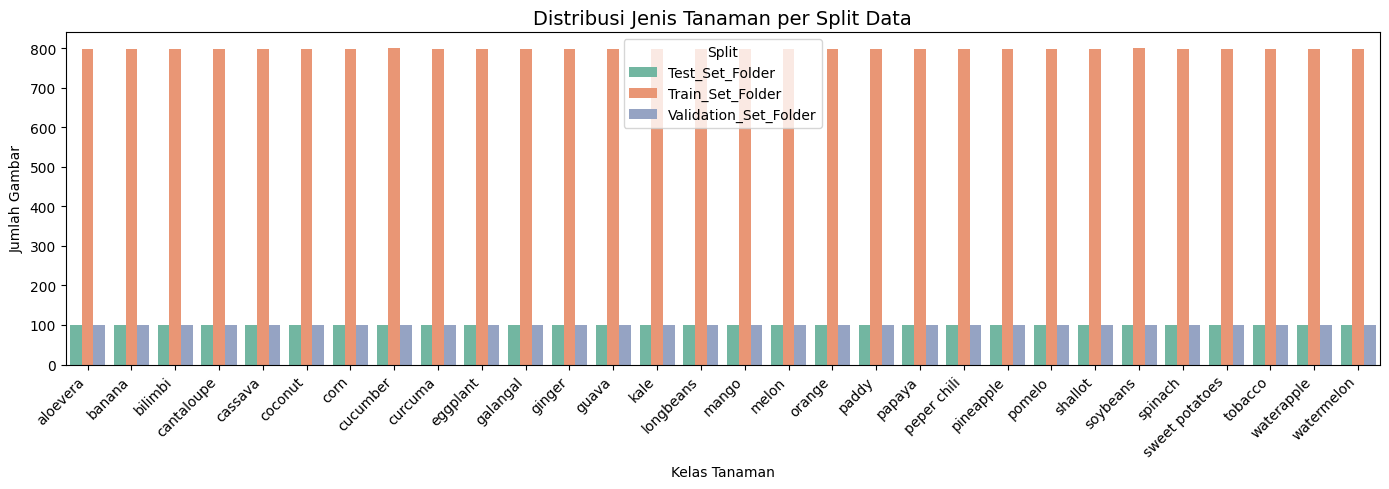

In [5]:
# ── 4.2 Bar-plot distribusi kelas ────────────────────────────────────────────
plt.figure(figsize=(14, 5))
sns.barplot(data=df_dist, x='class', y='count', hue='split', palette='Set2')
plt.title('Distribusi Jenis Tanaman per Split Data', fontsize=14)
plt.xlabel('Kelas Tanaman')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Split')
plt.tight_layout()
plt.show()

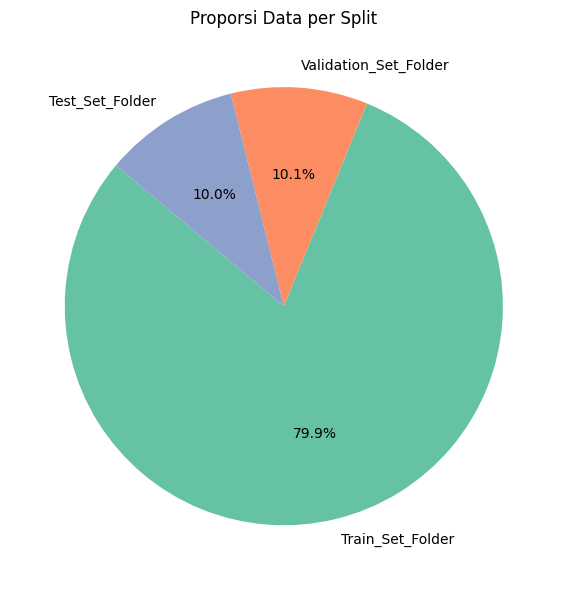

In [6]:
# ── 4.3 Pie-chart proporsi per split ─────────────────────────────────────────
split_counts = df_meta['split'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(split_counts.values, labels=split_counts.index,
        autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('Set2', len(split_counts)))
plt.title('Proporsi Data per Split')
plt.tight_layout()
plt.show()

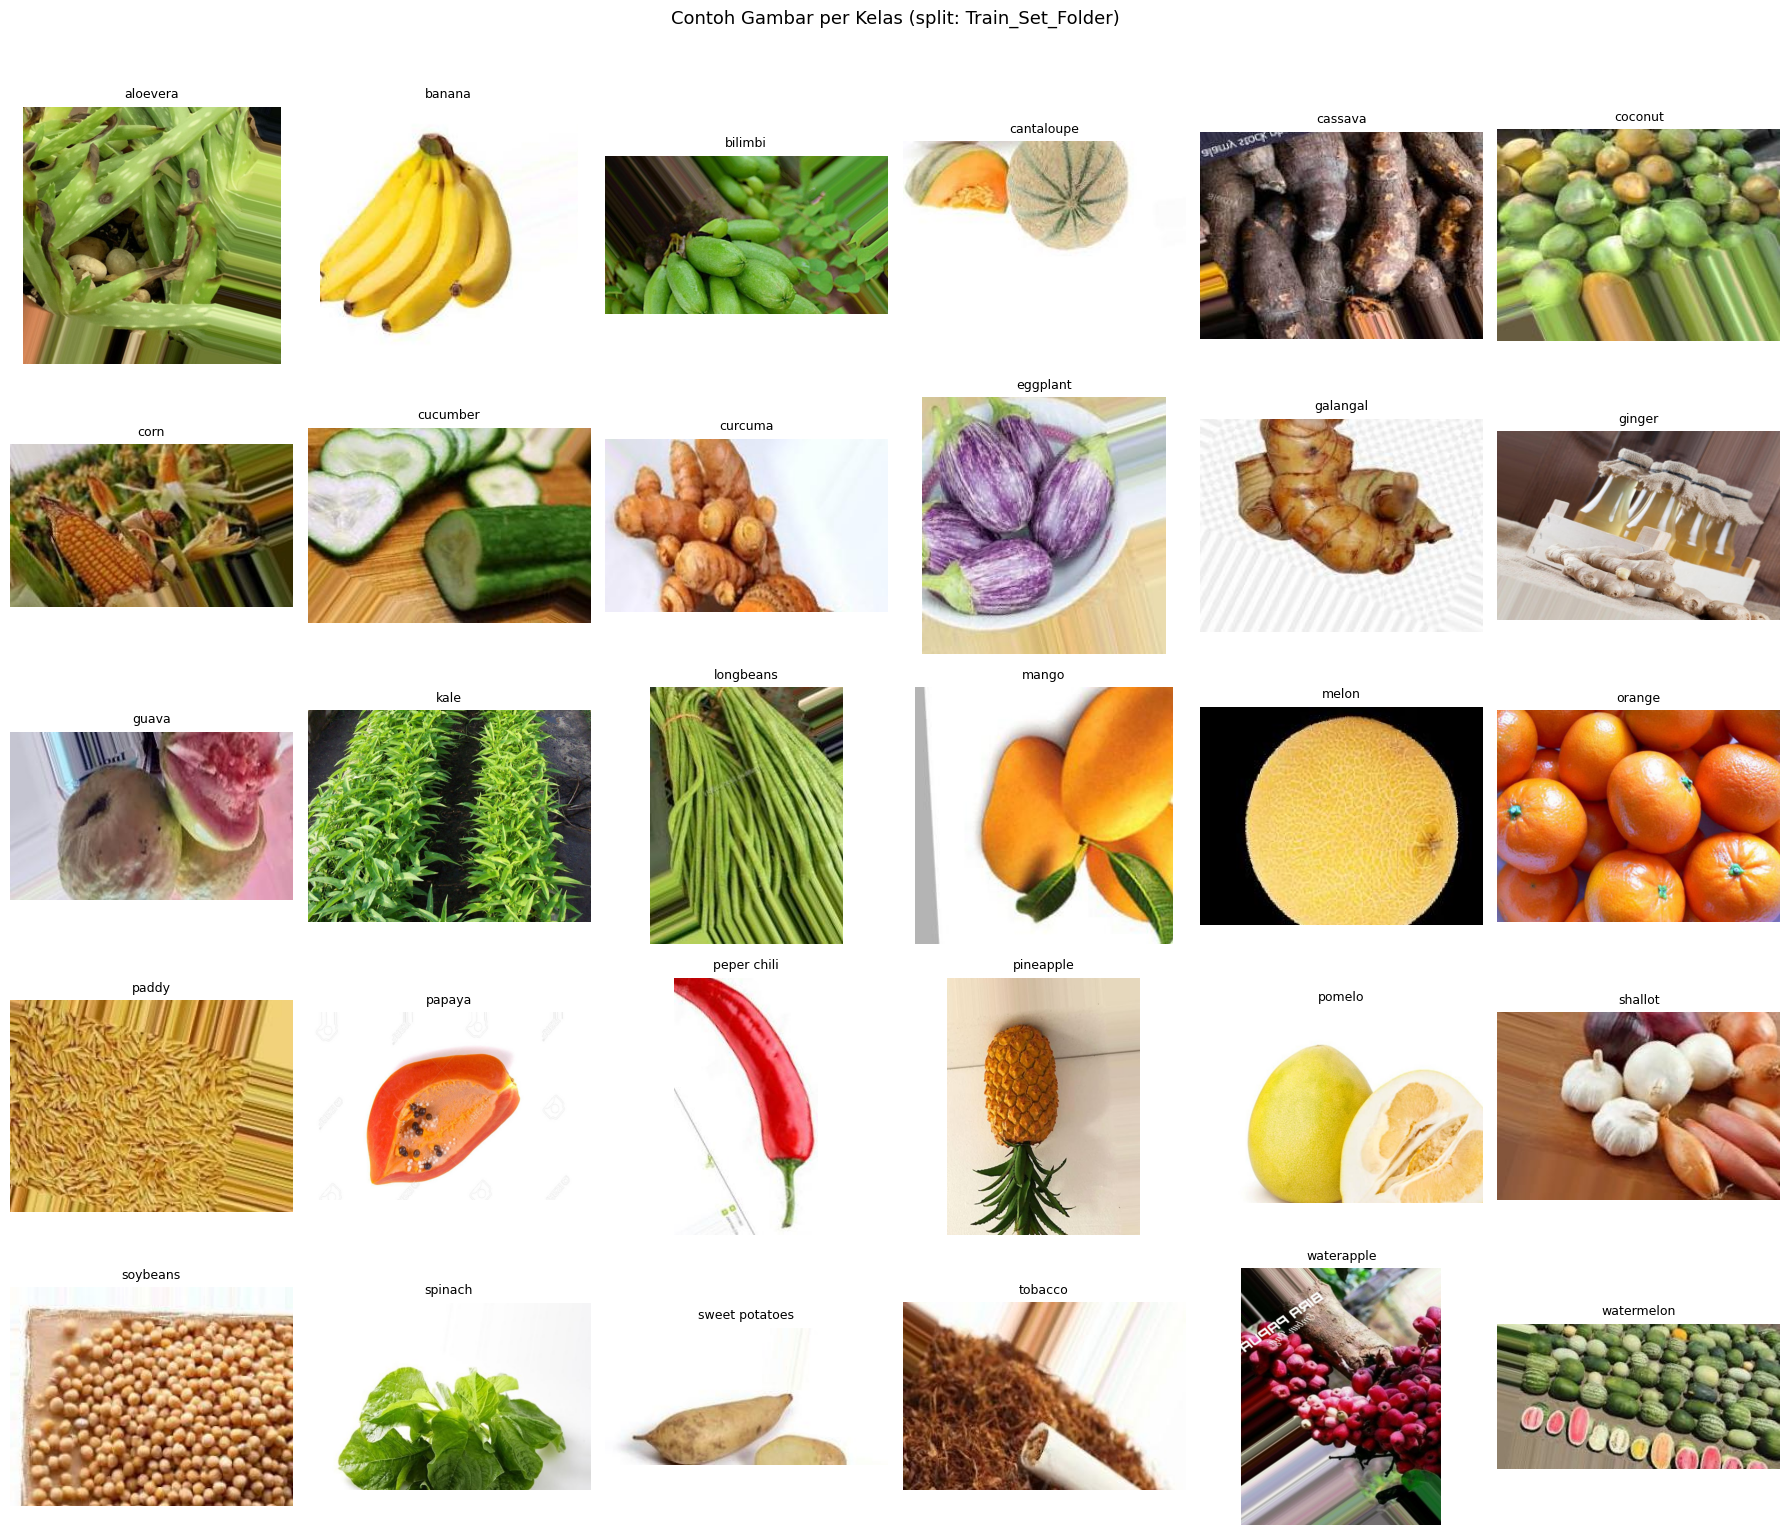

In [7]:
# ── 4.4 Tampilkan satu contoh gambar dari setiap kelas (split=Train_Set_Folder) ──
train_classes = df_meta[df_meta['split'] == 'Train_Set_Folder']['class'].unique()
n_classes = len(train_classes)

if n_classes == 0:
    print("⚠️  Tidak ada kelas ditemukan. Periksa nama split di df_meta.")
else:
    cols = min(n_classes, 6)
    rows = (n_classes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten() if rows * cols > 1 else [axes]

    for i, cls in enumerate(sorted(train_classes)):
        sample_row = df_meta[
            (df_meta['split'] == 'Train_Set_Folder') & (df_meta['class'] == cls)
        ].iloc[0]
        img = Image.open(sample_row['path'])
        axes[i].imshow(img)
        axes[i].set_title(cls, fontsize=9)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Contoh Gambar per Kelas (split: Train_Set_Folder)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

Lebar  gambar – min: 171, max: 3684, rata-rata: 479
Tinggi gambar – min: 140, max: 3684, rata-rata: 367


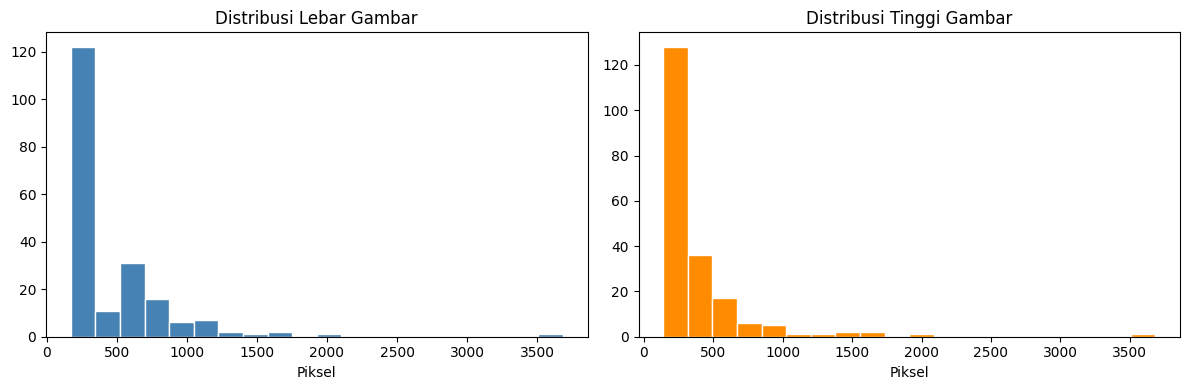

In [8]:
# ── 4.5 Analisis ukuran gambar dari sampel acak ───────────────────────────────
sample_df = df_meta.sample(min(200, len(df_meta)), random_state=42)
widths, heights = [], []

for _, row in sample_df.iterrows():
    try:
        with Image.open(row['path']) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception:
        pass

print(f'Lebar  gambar – min: {min(widths)}, max: {max(widths)}, rata-rata: {np.mean(widths):.0f}')
print(f'Tinggi gambar – min: {min(heights)}, max: {max(heights)}, rata-rata: {np.mean(heights):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Lebar Gambar'); axes[0].set_xlabel('Piksel')
axes[1].hist(heights, bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('Distribusi Tinggi Gambar'); axes[1].set_xlabel('Piksel')
plt.tight_layout(); plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Tahapan preprocessing yang dilakukan:
1. **Filter file valid** – hanya ekstensi gambar yang diizinkan
2. **Deteksi gambar rusak** – gambar yang tidak bisa dibuka dibuang
3. **Resize** – semua gambar diseragamkan ke `TARGET_SIZE = (128, 128)`
4. **Konversi RGB** – memastikan semua gambar memiliki 3 channel
5. **Normalisasi piksel** – nilai piksel dibagi 255 → rentang `[0, 1]`
6. **Encode label** – label kelas dikonversi ke indeks integer
7. **Simpan hasil** – array numpy disimpan ke `data/processed/`

Shape setelah preprocess : (128, 128, 3)
Tipe data                : float32
Nilai min / max piksel   : 0.0000 / 0.9725


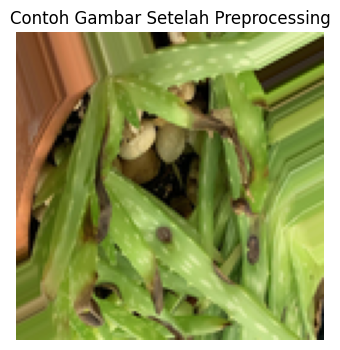

In [9]:
# ── 5.1 Fungsi preprocessing satu gambar (eksperimen manual) ─────────────────
VALID_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')

def preprocess_single_image(image_path: str,
                             target_size: tuple = (128, 128)) -> np.ndarray | None:
    if not image_path.lower().endswith(VALID_EXTS):
        return None
    try:
        with Image.open(image_path) as img:
            img = img.convert('RGB')
            img = img.resize(target_size, Image.LANCZOS)
            arr = np.array(img, dtype=np.float32) / 255.0
        return arr
    except Exception as e:
        print(f'  ⚠️  Gagal memproses {image_path}: {e}')
        return None


# ── Uji pada satu gambar ──────────────────────────────────────────────────────
sample_path = df_meta.iloc[0]['path']
result = preprocess_single_image(sample_path, TARGET_SIZE)
if result is not None:
    print(f'Shape setelah preprocess : {result.shape}')
    print(f'Tipe data                : {result.dtype}')
    print(f'Nilai min / max piksel   : {result.min():.4f} / {result.max():.4f}')

    plt.figure(figsize=(4, 4))
    plt.imshow(result)
    plt.title('Contoh Gambar Setelah Preprocessing')
    plt.axis('off')
    plt.show()

In [10]:
# ── 5.2 Preprocessing seluruh dataset (per split) ────────────────────────────
from collections import defaultdict

# ✅ Sesuaikan dengan nama folder aktual
VALID_SPLITS = ['Train_Set_Folder', 'Test_Set_Folder', 'Validation_Set_Folder']

def build_label_encoder(dataset_path: str, valid_splits: list) -> dict:
    classes = set()
    for split in valid_splits:
        split_path = os.path.join(dataset_path, split)
        if os.path.isdir(split_path):
            classes.update(c for c in os.listdir(split_path)
                           if os.path.isdir(os.path.join(split_path, c)))
    return {cls: idx for idx, cls in enumerate(sorted(classes))}


label_encoder = build_label_encoder(DATASET_PATH, VALID_SPLITS)
print('Label encoder (kelas → indeks):')
for k, v in label_encoder.items():
    print(f'  {v:>3}  →  {k}')

Label encoder (kelas → indeks):
    0  →  aloevera
    1  →  banana
    2  →  bilimbi
    3  →  cantaloupe
    4  →  cassava
    5  →  coconut
    6  →  corn
    7  →  cucumber
    8  →  curcuma
    9  →  eggplant
   10  →  galangal
   11  →  ginger
   12  →  guava
   13  →  kale
   14  →  longbeans
   15  →  mango
   16  →  melon
   17  →  orange
   18  →  paddy
   19  →  papaya
   20  →  peper chili
   21  →  pineapple
   22  →  pomelo
   23  →  shallot
   24  →  soybeans
   25  →  spinach
   26  →  sweet potatoes
   27  →  tobacco
   28  →  waterapple
   29  →  watermelon


In [11]:
# ── 5.3 Jalankan preprocessing dan kumpulkan array ────────────────────────────
processed_data = defaultdict(lambda: {'X': [], 'y': []})
skipped = 0

for _, row in df_meta.iterrows():
    arr = preprocess_single_image(row['path'], TARGET_SIZE)
    if arr is None:
        skipped += 1
        continue
    processed_data[row['split']]['X'].append(arr)
    processed_data[row['split']]['y'].append(label_encoder[row['class']])

print(f'Gambar dilewati (error/format) : {skipped}')
for split in processed_data:
    X = np.array(processed_data[split]['X'])
    y = np.array(processed_data[split]['y'])
    processed_data[split]['X'] = X
    processed_data[split]['y'] = y
    print(f'[{split}]  X shape: {X.shape}, y shape: {y.shape}')

Gambar dilewati (error/format) : 0
[Test_Set_Folder]  X shape: (2998, 128, 128, 3), y shape: (2998,)
[Train_Set_Folder]  X shape: (23972, 128, 128, 3), y shape: (23972,)
[Validation_Set_Folder]  X shape: (3030, 128, 128, 3), y shape: (3030,)


In [12]:
# ── 5.4 Simpan hasil ke disk ──────────────────────────────────────────────────
OUTPUT_DIR = '../data/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for split in processed_data:
    np.save(os.path.join(OUTPUT_DIR, f'X_{split}.npy'), processed_data[split]['X'])
    np.save(os.path.join(OUTPUT_DIR, f'y_{split}.npy'), processed_data[split]['y'])
    print(f'Tersimpan: X_{split}.npy, y_{split}.npy')

# Simpan juga label_encoder sebagai CSV agar mudah dibaca
pd.DataFrame(list(label_encoder.items()), columns=['class', 'label_index']) \
  .to_csv(os.path.join(OUTPUT_DIR, 'label_encoder.csv'), index=False)
print('Tersimpan: label_encoder.csv')
print(f'\n✅  Preprocessing selesai. File tersimpan di "{OUTPUT_DIR}"')

Tersimpan: X_Test_Set_Folder.npy, y_Test_Set_Folder.npy
Tersimpan: X_Train_Set_Folder.npy, y_Train_Set_Folder.npy
Tersimpan: X_Validation_Set_Folder.npy, y_Validation_Set_Folder.npy
Tersimpan: label_encoder.csv

✅  Preprocessing selesai. File tersimpan di "../data/processed"
